In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Load + basic cleaning

In [2]:

df = pd.read_parquet("sa_ca_sp")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["id", "date"]).reset_index(drop=True)

## Split train/val/test

In [3]:
HORIZON = 28

def split_data(df, horizon=28):
    train, val, test = [], [], []

    for _, g in df.groupby("id"):
        g = g.sort_values("date")

        train.append(g.iloc[:-2*horizon])
        val.append(g.iloc[-2*horizon:-horizon])
        test.append(g.iloc[-horizon:])

    return (
        pd.concat(train),
        pd.concat(val),
        pd.concat(test)
    )

train_df, val_df, test_df = split_data(df, HORIZON)


## Seasonal Naive

In [4]:
def seasonal_naive_fast(full_df, season=28):
    df_ = full_df.copy()
    df_["sn_pred"] = df_.groupby("id")["sales"].shift(season)
    return df_

## Metrics helpers (MAE/RMSE/MAPE/WRMSSE)

In [5]:
def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

def compute_wrmsse(train_df, eval_df, pred_col="sn_pred", target_col="sales", id_col="id"):
    """
    Practical WRMSSE for your setup:
    - RMSSE per id uses scale = mean((diff(train))^2)
    - weights use total train sales per id (normalized)
    - WRMSSE = sum_i w_i * RMSSE_i
    """
    # weights (normalize)
    w = train_df.groupby(id_col)[target_col].sum().astype("float64")
    w = w / w.sum()

    # scale per series (mean squared diff of training)
    scale = train_df.groupby(id_col)[target_col].apply(lambda x: np.mean(np.diff(x.values) ** 2) if len(x) > 1 else np.nan)

    # join eval preds/truth by id
    g_eval = eval_df.groupby(id_col)

    rmsse_parts = []
    for series_id, g in g_eval:
        y_true = g[target_col].values
        y_pred = g[pred_col].values

        s = scale.get(series_id, np.nan)
        if not np.isfinite(s) or s == 0 or len(y_true) == 0:
            continue

        mse = np.mean((y_true - y_pred) ** 2)
        rmsse = np.sqrt(mse / s)
        rmsse_parts.append((series_id, rmsse))

    if len(rmsse_parts) == 0:
        return np.nan

    rmsse_by_id = pd.Series(dict(rmsse_parts))
    # align weights
    w_aligned = w.reindex(rmsse_by_id.index).fillna(0.0)
    return float((w_aligned * rmsse_by_id).sum())


def metrics_row(train_df, eval_df, name, pred_col="sn_pred"):
    y_true = eval_df["sales"].values
    y_pred = eval_df[pred_col].values

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mape_safe(y_true, y_pred)
    wrmsse = compute_wrmsse(train_df, eval_df, pred_col=pred_col)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "WRMSSE": wrmsse
    }

## Validation predictions + evaluation

In [6]:
full_val = pd.concat([train_df, val_df])  # :contentReference[oaicite:6]{index=6}
sn_all_val = seasonal_naive_fast(full_val, season=HORIZON)
sn_val = sn_all_val.loc[sn_all_val.index.isin(val_df.index)].dropna(subset=["sn_pred"])  # :contentReference[oaicite:7]{index=7}


## Test predictions + evaluation

In [7]:
full_test = pd.concat([train_df, val_df, test_df])  # :contentReference[oaicite:8]{index=8}
sn_all_test = seasonal_naive_fast(full_test, season=HORIZON)
sn_test = sn_all_test.loc[sn_all_test.index.isin(test_df.index)].dropna(subset=["sn_pred"])  # :contentReference[oaicite:9]{index=9}


## Print all the evaluation results

In [8]:
results = []
results.append(metrics_row(train_df, sn_val,  "Seasonal Naive - Validation", pred_col="sn_pred"))
results.append(metrics_row(pd.concat([train_df, val_df]), sn_test, "Seasonal Naive - Test", pred_col="sn_pred"))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                      Model      MAE    RMSE      MAPE   WRMSSE
Seasonal Naive - Validation 1.191831 2.90164 68.986313 1.010564
      Seasonal Naive - Test 1.175972 3.16472 68.020964 1.025874


## Plot actual vs prediction

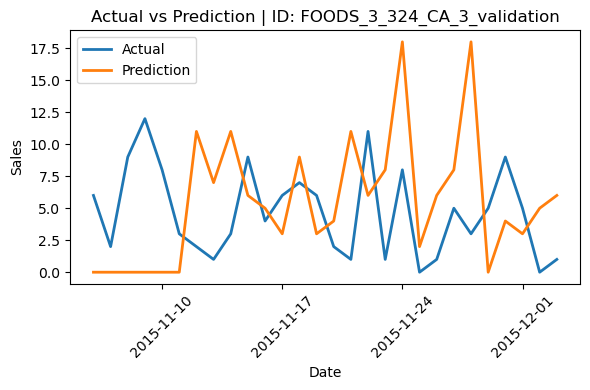

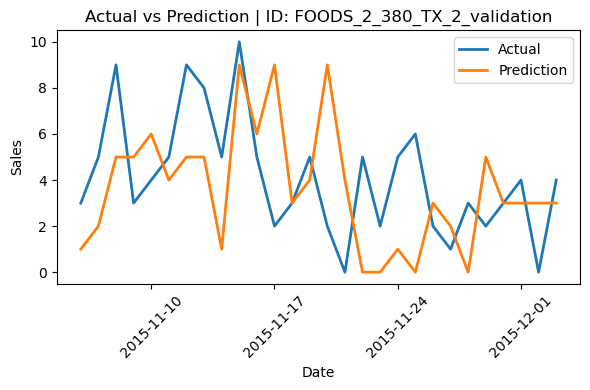

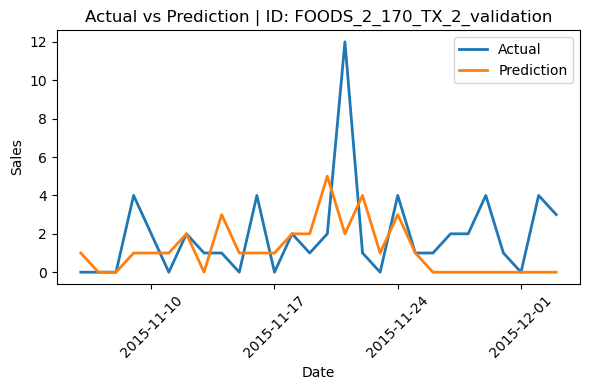

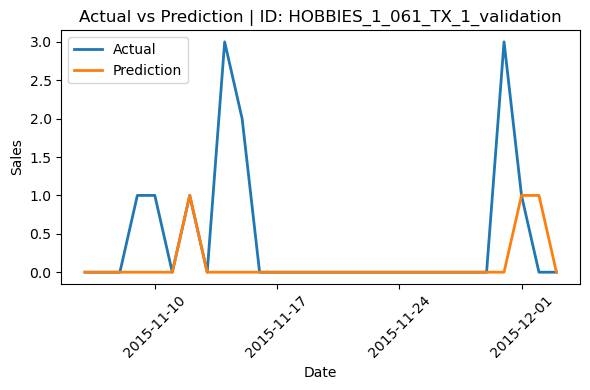

In [ ]:
valid_ids = (
    sn_val.groupby("id")["sales"]
    .sum()
    .loc[lambda x: x > 0]
    .index
)

np.random.seed(42)
selected_ids = np.random.choice(valid_ids, size=4, replace=False)


def plot_actual_vs_pred(series_id):
    df_plot = sn_val[sn_val["id"] == series_id]

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(df_plot["date"], df_plot["sales"], label="Actual", linewidth=2)
    ax.plot(df_plot["date"], df_plot["sn_pred"], label="Prediction", linewidth=2)

    ax.set_title(f"Actual vs Prediction | ID: {series_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")
    ax.legend()

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


for sid in selected_ids:
    plot_actual_vs_pred(sid)

## Residual time series (Error over time)

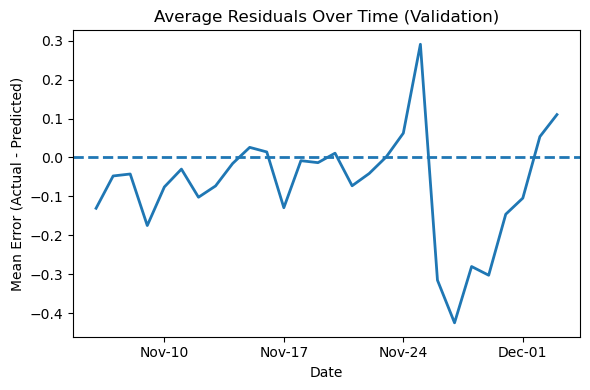

In [ ]:
daily_residuals = (
    sn_val.assign(residual=sn_val["sales"] - sn_val["sn_pred"])
          .groupby("date")["residual"]
          .mean()
)

plt.figure(figsize=(6, 4))
plt.plot(daily_residuals.index, daily_residuals.values, linewidth=2)

plt.axhline(0, linestyle="--", linewidth=2)

plt.title("Average Residuals Over Time (Validation)")
plt.xlabel("Date")
plt.ylabel("Mean Error (Actual - Predicted)")

# -------- FIX DATE FORMATTING --------
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))   # weekly ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))    # Nov-05
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Residual Distribution 

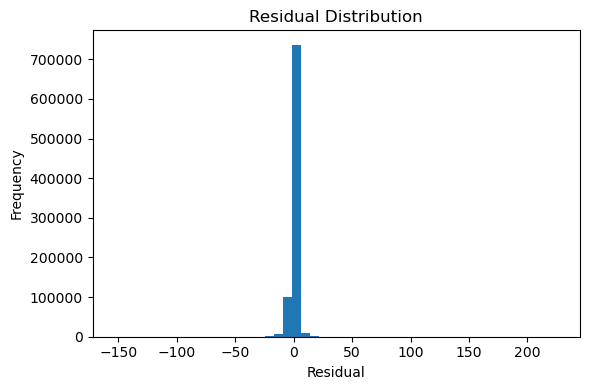

In [32]:
plt.figure(figsize=(6, 4))
plt.hist(sn_val["residual"], bins=50)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()